### Polynomial Distribution Fitting with PyTorch

In this notebook, I demonstrate my ability to code using PyTorch by building a model to fit a polynomial distribution. I trained and tested a model based on the  "Ice Cream Selling" dataset, which captures the relationship between temperature and ice cream sales.

The primary goal of this project is to showcase essential PyTorch skills required for machine learning, including model building, training, and evaluation. The project also covers the fundamental PyTorch workflow: processing historical data, building an algorithm (such as a neural network) to uncover patterns, and using those patterns to make predictions about unseen data, such as the future. The workflow in this notebook is adapted from a PyTorch tutorial on linear regression and Python workflows (https://www.learnpytorch.io/01_pytorch_workflow).

In this notebook, I build upon the tutorial by adapting the workflow and applying it to a real-world dataset. Key enhancements include better data preparation (such as shuffling the data) and using a polynomial regression model instead of a simple linear model. This showcases how PyTorch can be effectively used in practical scenarios.

In [23]:
# Import PyTorch and matplotlib
import torch
from torch import nn # nn contains all of PyTorch's building blocks for neural networks
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.5.1+cu121'

In [2]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# Prepare and load data (hard coding in this case, just a simple model)

First, hard coding some weight and bias values.

Then makinga range of numbers between 0 and 1, these will be our X values.

Finally, using the X values, as well as the weight and bias values to create y using the linear regression formula (y = weight * X + bias).

In [ ]:
# Basic Hard Coded Quadratic Relationship
# set target parameters
#a = quadratic_coefficient = 0.5
#b = linear_coefficient = -0.3
#c = constant_term = 0.7

# Create range values
#start = 0
#end = 1
#step = 0.02

# Create X and y (features and labels) (dataset)
#X = torch.arange(start, end, step).unsqueeze(dim=1) # without unsqueeze, errors will happen later on (shapes within linear layers)
#y = a * X**2 + b * X + c
#X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.7000],
         [0.6942],
         [0.6888],
         [0.6838],
         [0.6792],
         [0.6750],
         [0.6712],
         [0.6678],
         [0.6648],
         [0.6622]]))

In [4]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Verify the file path
!ls "/content/drive/My Drive/Kaggle"


Mounted at /content/drive
'Ice_cream selling data.csv'


In [5]:
import pandas as pd

# Define the path to the dataset
file_path = '/content/drive/My Drive/Kaggle/Ice_cream selling data.csv'

# Load the dataset
data = pd.read_csv(file_path)

# Inspect the first few rows of the dataset
print(data.head())


   Temperature (°C)  Ice Cream Sales (units)
0         -4.662263                41.842986
1         -4.316559                34.661120
2         -4.213985                39.383001
3         -3.949661                37.539845
4         -3.578554                32.284531


In [7]:
X = torch.tensor(data['Temperature (°C)'].values, dtype=torch.float32).unsqueeze(dim=1)
y = torch.tensor(data['Ice Cream Sales (units)'].values, dtype=torch.float32).unsqueeze(dim=1)

# Check the shapes
print(X.shape, y.shape)


torch.Size([49, 1]) torch.Size([49, 1])


splitting data into training and test sets - 80/20 split.

In [8]:
def shuffle_and_split(X, y, train_split_ratio=0.8):
    """
    Shuffle and split the data into training and testing sets.

    Args:
        X (torch.Tensor): Features.
        y (torch.Tensor): Labels.
        train_split_ratio (float): Ratio of the data to be used for training (default is 0.8).

    Returns:
        tuple: (X_train, y_train, X_test, y_test)
    """
    # Combine X and y into a dataset
    dataset = torch.utils.data.TensorDataset(X, y)

    # Shuffle the dataset
    shuffled_dataset = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=True)

    # Extract shuffled data
    shuffled_X, shuffled_y = next(iter(shuffled_dataset))

    # Calculate train split index
    train_split = int(train_split_ratio * len(shuffled_X))

    # Split the data
    X_train, y_train = shuffled_X[:train_split], shuffled_y[:train_split]
    X_test, y_test = shuffled_X[train_split:], shuffled_y[train_split:]

    return X_train, y_train, X_test, y_test


In [9]:
# Shuffle and split the data
X_train, y_train, X_test, y_test = shuffle_and_split(X, y, train_split_ratio=0.8)

# Check the lengths
print(f"training data_features: {len(X_train)}, training data_labels: {len(y_train)}, testing data_features {len(X_test)}, testing data_labels: {len(y_test)}")


training data_features: 39, training data_labels: 39, testing data_features 10, testing data_labels: 10


In [10]:
# visualize data
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="y", s=8, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=6, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

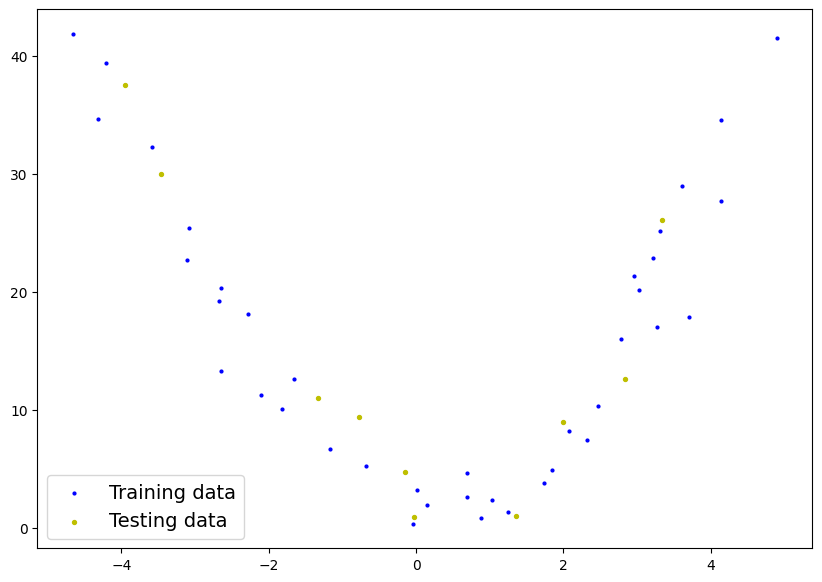

In [11]:
plot_predictions(X_train, y_train, X_test, y_test)

## Building a PyTorch linear model

In [12]:
# Subclass nn.Module to make our model
class PolynomialRegressionModel(nn.Module):
    def __init__(self, degree: int):
        super().__init__()
        self.degree = degree
        # Define the coefficients for the polynomial as learnable parameters
        self.coefficients = nn.Parameter(torch.randn(degree, requires_grad=True)) # coefficients
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))  # constant term

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Calculate the polynomial terms
        poly_terms = torch.stack([x**i for i in range(1, self.degree + 1)], dim=-1)
        # Perform the polynomial computation
        y = poly_terms @ self.coefficients.unsqueeze(-1) + self.bias
        return y.squeeze(-1)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
degree = 2
model_1 = PolynomialRegressionModel(degree=degree)
model_1, model_1.state_dict()

(PolynomialRegressionModel(),
 OrderedDict([('coefficients', tensor([0.3367, 0.1288])),
              ('bias', tensor([0.2345]))]))

In [13]:
# Check model device
next(model_1.parameters()).device

device(type='cpu')

In [14]:
# Set model to GPU if it's available, otherwise it'll default to CPU
model_1.to(device) # the device variable was set above to be "cuda" if available or "cpu" if not
next(model_1.parameters()).device

device(type='cpu')

## Training
# build a training and testing loop.

In [15]:
# Create loss function
loss_fn = nn.L1Loss()

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), # optimize newly created model's parameters
                            lr=0.01)

In [16]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 1000000

# Put data on the available device
# Without this, error will happen (not all model/data on device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train() # train mode is on by default after construction

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero grad optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval() # put the model in evaluation mode for testing (inference)
    # 1. Forward pass
    with torch.inference_mode():
        test_pred = model_1(X_test)

        # 2. Calculate the loss
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100000 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 15.006607055664062 | Test loss: 12.863981246948242
Epoch: 100000 | Train loss: 2.5304267406463623 | Test loss: 3.052375316619873
Epoch: 200000 | Train loss: 2.534503221511841 | Test loss: 3.061086893081665
Epoch: 300000 | Train loss: 2.5319526195526123 | Test loss: 3.0357260704040527
Epoch: 400000 | Train loss: 2.53585147857666 | Test loss: 3.023751735687256
Epoch: 500000 | Train loss: 2.5315725803375244 | Test loss: 3.039647340774536
Epoch: 600000 | Train loss: 2.5303258895874023 | Test loss: 3.0450515747070312
Epoch: 700000 | Train loss: 2.536760091781616 | Test loss: 3.0540614128112793
Epoch: 800000 | Train loss: 2.5368239879608154 | Test loss: 3.0528063774108887
Epoch: 900000 | Train loss: 2.5374908447265625 | Test loss: 3.029811382293701


In [27]:
# Find the model's learned parameters
print("The model learned the following values for coefficients and bias:")
print(model_1.state_dict())

The model learned the following values for coefficients and bias:
OrderedDict([('coefficients', tensor([-1.0177,  1.8320])), ('bias', tensor([2.3808]))])



## 6.4 Making predictions

In [18]:
# Set model to evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
    y_preds = model_1(X_test)
y_preds

tensor([[ 4.3846],
        [14.1899],
        [ 4.2635],
        [ 6.9537],
        [19.3737],
        [34.9798],
        [27.7757],
        [ 7.6693],
        [ 2.4174],
        [ 2.5741]])

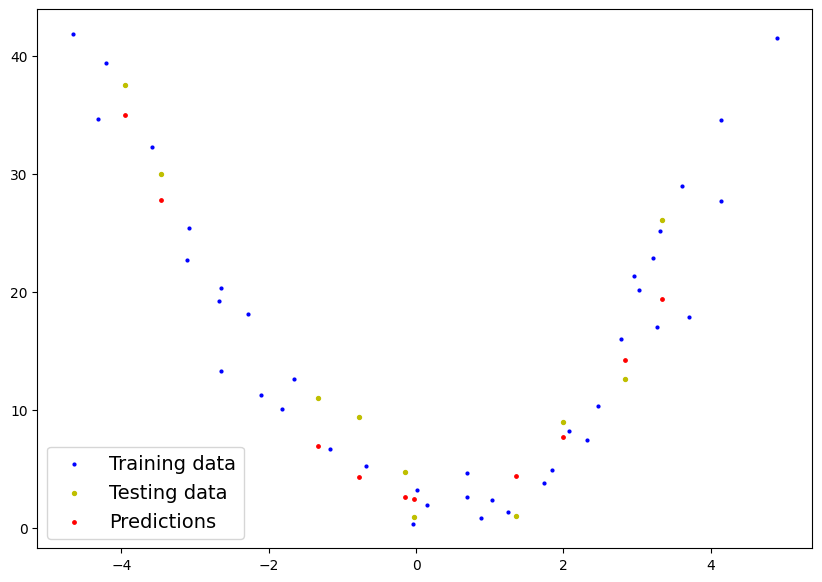

In [19]:
plot_predictions(predictions=y_preds) # -> won't work if data not on CPU

# if not on CPU, put data on the CPU and plot it
#plot_predictions(predictions=y_preds.cpu())

Saving and loading the model

In [20]:
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_1.pth


In [21]:
# Instantiate a fresh instance of PolynomialRegressionModel
loaded_model_1 = PolynomialRegressionModel(degree = degree)

# Load model state dict
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))

# Put model to target device (if your data is on GPU, model will have to be on GPU to make predictions)
loaded_model_1.to(device)

print(f"Loaded model:\n{loaded_model_1}")
print(f"Model on device:\n{next(loaded_model_1.parameters()).device}")

Loaded model:
PolynomialRegressionModel()
Model on device:
cpu


<ipython-input-21-7ba71622215b>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))


In [22]:
# Evaluate loaded model
loaded_model_1.eval()
with torch.inference_mode():
    loaded_model_1_preds = loaded_model_1(X_test)
y_preds == loaded_model_1_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])